In [1]:
import tqdm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns

In [2]:
%load_ext autoreload
%autoreload 2
import os

os.chdir("../../../notebooks/ChopTFs/pipeline/")
import time_normalization_helpers
import speed_plotting_helpers

In [3]:
activities = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/activities_to_fit.csv", index_col = 0)
activities

,ADseq,time,activity,ci_low,ci_hi,n_barcodes,class,error,activity_norm,ci_low_norm,ci_hi_norm
14,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,0,0.603252,0.489177,0.723339,2,ns,0.059735,0.000000,-0.114075,0.120087
15,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,5,0.849635,0.104610,1.406962,2,ns,0.332233,0.246383,-0.498641,0.803710
16,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,10,1.384974,0.885289,1.855112,2,activator,0.247404,0.781723,0.282038,1.251861
17,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,15,1.590645,0.729068,2.033041,2,ns,0.332646,0.987393,0.125816,1.429790
18,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS,30,1.813740,1.245708,2.308080,2,activator,0.271013,1.210488,0.642456,1.704829
...,...,...,...,...,...,...,...,...,...,...,...
27514,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,0,0.317346,0.084921,0.504546,3,ns,0.107047,0.000000,-0.232424,0.187201
27515,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,5,2.505254,2.376353,2.630862,3,activator,0.064926,2.187908,2.059007,2.313516
27516,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,10,3.162542,3.082389,3.263605,3,activator,0.046229,2.845196,2.765043,2.946259
27517,YTRGSHPASSDLDLDDFAAFDGGASTTTYSSPAMPNLFDM,15,3.419411,3.326929,3.520471,3,activator,0.049373,3.102066,3.009583,3.203125


In [4]:
import numpy as np
from scipy.optimize import curve_fit

def make_feasible(p0, lb, ub):
    eps = 1e-6
    return np.minimum(np.maximum(p0, np.array(lb) + eps), np.array(ub) - eps)
    
def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

def weighted_r2(y, y_pred, sigma):
    w = 1 / np.clip(sigma, 1e-6, None)**2
    y_wmean = np.sum(w * y) / np.sum(w)

    ss_res = np.sum(w * (y - y_pred)**2)
    ss_tot = np.sum(w * (y - y_wmean)**2)

    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan


def compute_t_half_obs(t, popt, obs_max):
    # dense grid for smooth interpolation
    t_grid = np.linspace(np.min(t), np.max(t), 500)
    y_fit = hill(t_grid, *popt)

    target = 0.5 * obs_max

    # find closest point
    idx = np.argmin(np.abs(y_fit - target))
    return t_grid[idx]


def fit_hill(df):
    df = df.sort_values("time")

    t = df["time"].values.astype(float)
    y = df["activity_norm"].values.astype(float)
    sigma = df["error"].values.astype(float)
    sigma = np.clip(sigma, 1e-6, None)

    # initial guesses
    lb = [0, 0, 0.5]
    ub = [np.max(y) * 3, np.max(t)*10 if np.max(t) > 0 else 10, 5]
    
    # initial guesses
    Vmax0 = np.max(y)
    K0 = np.median(t[t > 0]) if np.any(t > 0) else 1.0
    n0 = 2.0
    
    p0 = [Vmax0, K0, n0]
    p0 = make_feasible(p0, lb, ub)

    try:
        popt, pcov = curve_fit(
            hill,
            t,
            y,
            p0=p0,
            sigma=sigma,
            absolute_sigma=True,
            bounds=(lb, ub)
        )

        y_pred = hill(t, *popt)
        r2 = weighted_r2(y, y_pred, sigma)

        # model-derived max (was np.max(y))
        t_grid = np.linspace(np.min(t), np.max(t), 500)
        obs_max = np.max(hill(t_grid, *popt))

        t_half_obs = compute_t_half_obs(t, popt, obs_max)

        return {
            "Vmax": popt[0],
            "K_fit": popt[1],
            "n": popt[2],
            "r2": r2,
            "obs_max": obs_max,
            "t_half_obs": t_half_obs,
            "success": True
        }

    except RuntimeError:
        return {
            "Vmax": np.nan,
            "K_fit": np.nan,
            "n": np.nan,
            "r2": np.nan,
            "obs_max": np.nan,
            "t_half_obs": np.nan,
            "success": False
        }

In [5]:
results = []

for ad, subdf in tqdm.tqdm(activities.groupby("ADseq")):
    fit = fit_hill(subdf)
    fit["ADseq"] = ad
    results.append(fit)

results_df = pd.DataFrame(results)
results_df

100%|██████████| 1709/1709 [00:09<00:00, 178.45it/s]


,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,1.244459,8.346715,2.599885,0.999485,1.201293,8.116232,True,AADLNSNNSFDSGASLMPAFQAGAFNMDQVSAFTAINDHS
1,2.539518,5.614880,1.208564,0.996085,2.243477,4.629259,True,AADVDLDDFTVFEGGASTAFSSPAVASSFDFSSGASSAAS
2,2.179818,4.715282,1.350423,0.994071,2.014279,4.208417,True,AADVELEEFTAFEGGANTAFSSPAVPTVFDFNSASSSTSN
3,2.729173,4.913649,1.383259,0.999732,2.522634,4.388778,True,AADVELPEEFTAFDGGANTAFSSPAVPSVFDFGGSSSSSI
4,2.671846,54.003363,1.245457,0.979431,0.867616,14.488978,True,AADYRPGPTLFPSPETVKFWMPLWKFRQQFSAKYRACHPT
...,...,...,...,...,...,...,...,...
1704,1.592590,10.418464,2.172270,0.985379,1.447129,9.559118,True,YSGLQSDYSPLTGVHDTSSPSIGPTISPRELLMNPPTSTA
1705,1.351511,17.125322,2.348352,0.943513,1.065817,14.248497,True,YSHMLTHVADLNSNNSFDSGASLMPAFQAGGFSLEQVSAF
1706,6.996872,10.825656,0.500000,0.999901,4.371099,2.224449,True,YSLFDSPSEGYETSPLFNTNDDLDDSNGWYSLFPPTTTSS
1707,2.816670,4.815398,1.658172,0.982248,2.687277,4.569138,True,YSSPGAPAVFDLPGASNHVGTISPQDLLIQDPYMSAPNST


In [6]:
ok = results_df[results_df["r2"] >= 0.7]
print(f"Keeping {len(ok)} / {len(results_df)} sequences ({100*len(ok)/len(results_df):.1f}%)")

Keeping 1704 / 1709 sequences (99.7%)


In [7]:
ok.to_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/output/GCN4_pipeline/speed/hill_fit_baseline_norm.csv")

In [8]:
not_ok = results_df[results_df["r2"] < 0.7]
not_ok

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
113,2.489176,8.495407e+01,1.150785,0.360244,0.577127,14.549098,True,AVINHFRGRRLWTMEEVWEKGVLDTATHIPAVFLGVLLNV
251,0.465531,3.781718e-07,2.941693,0.291015,0.465531,0.060120,True,DSTIAPYSRHHSVFGKFAAHEAARESFWGTTGAGAPLTPL
1202,0.630931,1.506220e-15,1.588221,0.441817,0.630931,5.110220,True,SAPNSTALTALTSPSIYNESPDFNDGYDVSPSFDSGDFGS
1220,1.226640,1.400336e+01,0.500000,0.608353,0.728750,2.525050,True,SDLPPLPPTPNQPSVNFEHSNQPHISFEDQPLFPPPSRPQ
1450,3.216284,6.731621e+01,1.060042,0.655344,0.958527,12.985972,True,SYRSPSSYSHSRTHSVNSQHCQPEATIHPSPILHPSVAAK


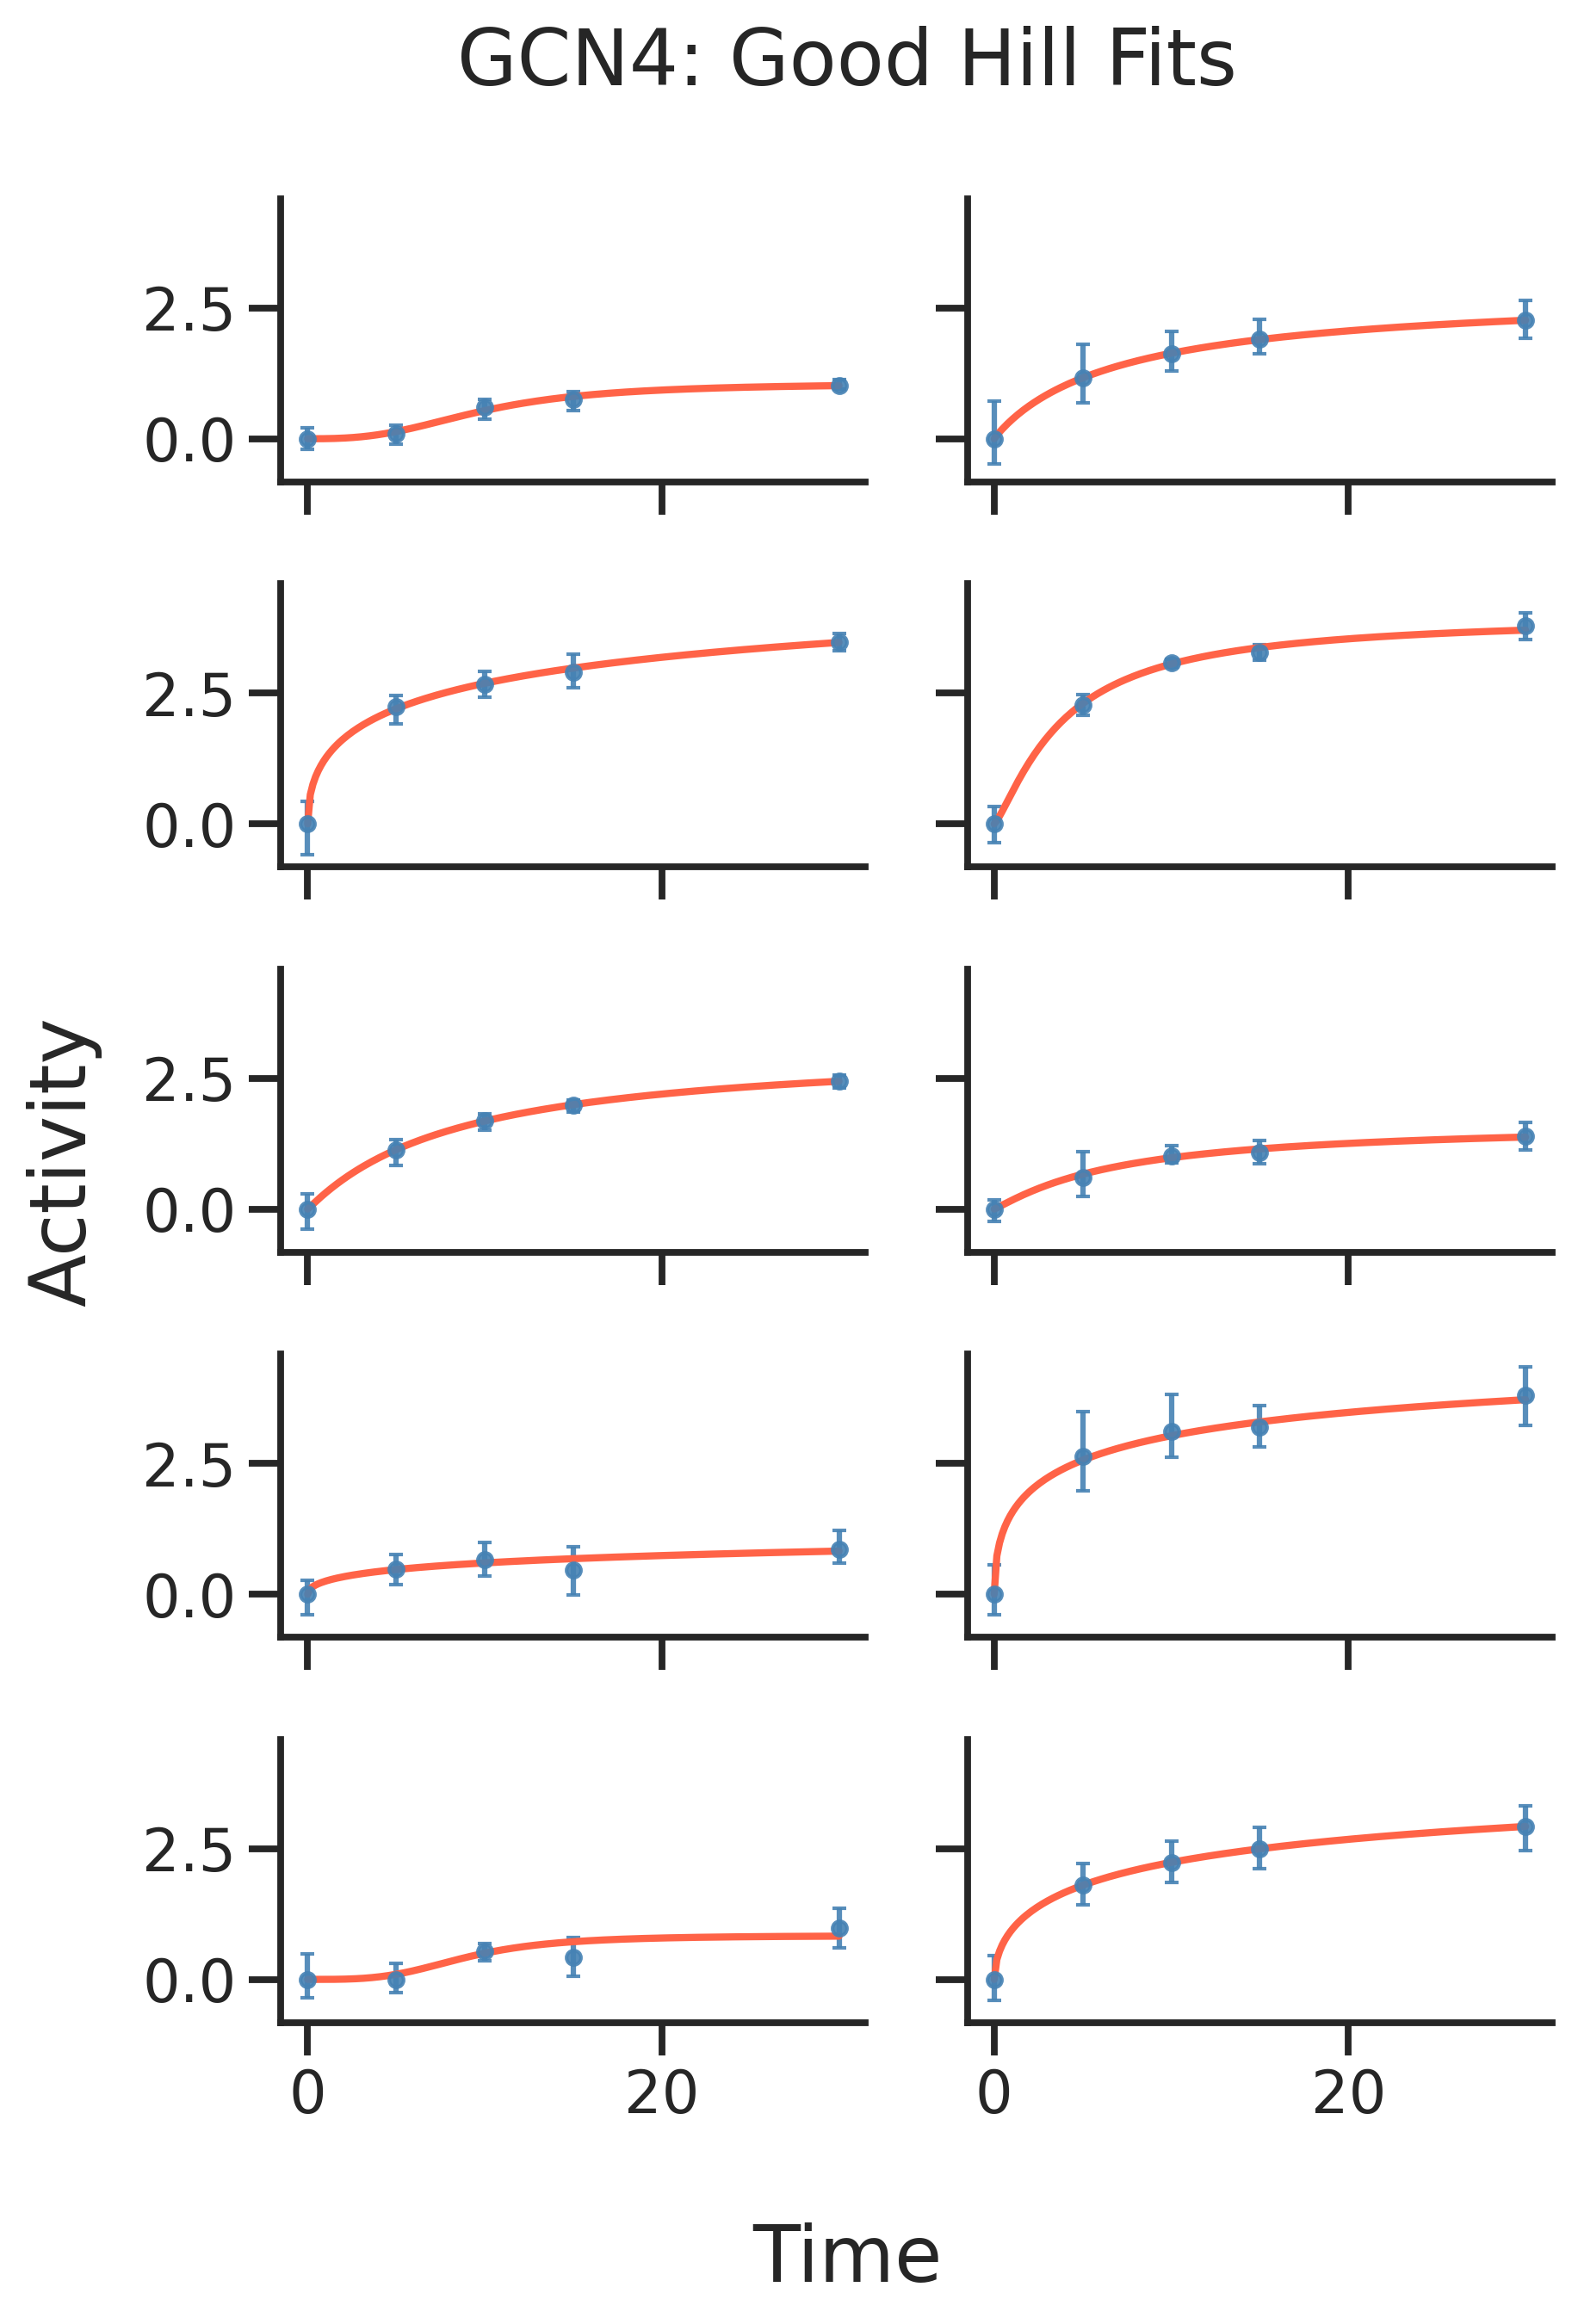

In [10]:
for df, title in zip([ok], ["Good"]):
    sample_adseqs = df.sample(16, random_state=44)['ADseq'].values

    speed_plotting_helpers.plot_model_fits(
        activities=activities,
        fit_results=results_df,
        sample_adseqs=sample_adseqs,
        model_fn=hill,
        model_params=['Vmax', 'K_fit', 'n'],
        y_col='activity_norm',
        ci_low_col='ci_low_norm',
        ci_hi_col='ci_hi_norm',
        title=f'GCN4: {title} Hill Fits',
    )

Pearson r = -0.664, p = 1.85e-217
Spearman rho = -0.722, p = 1.61e-274


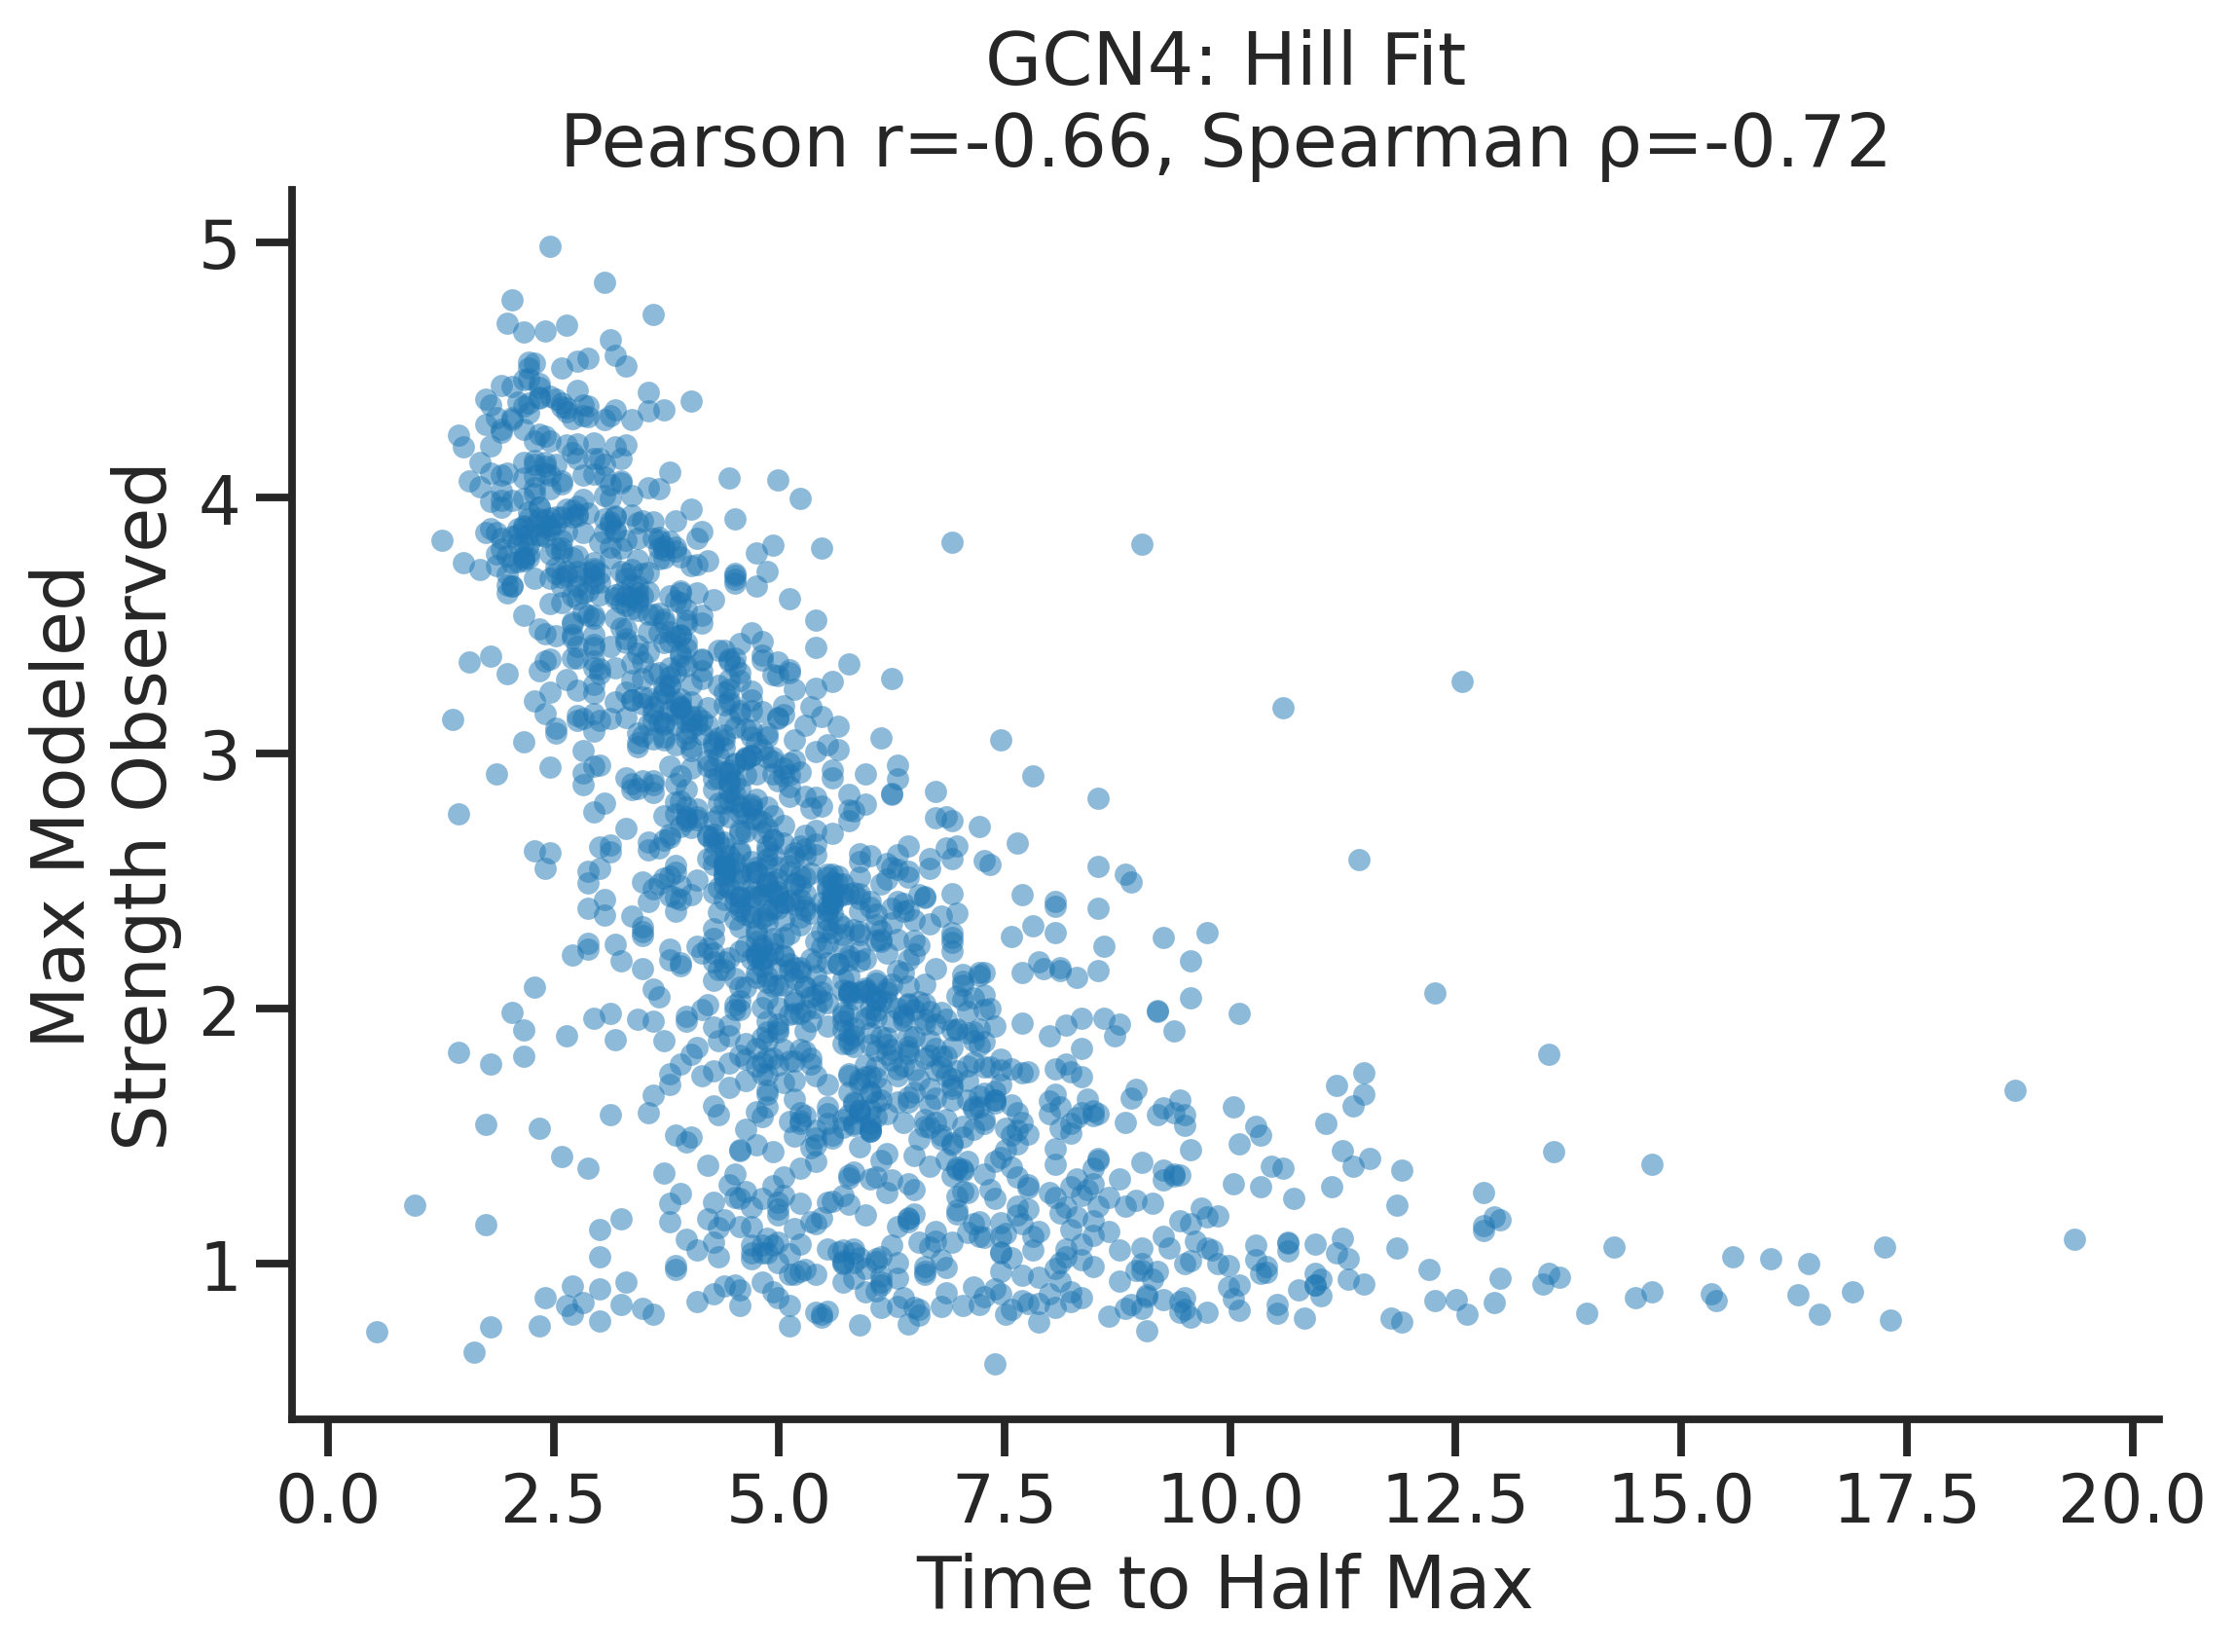

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)


ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

In [12]:
# --- filter valid sequences ---
filtered = ok[
    (ok['t_half_obs'] >= 0) &
    (ok['obs_max'] >= 0) 
].copy()

# --- 1. Similar strength (A), different speed (k) ---
A_target = filtered['obs_max'].median()
A_tol = filtered['obs_max'].std() * 0.5

similar_A = filtered[(filtered['obs_max'] >= A_target - A_tol) &
                     (filtered['obs_max'] <= A_target + A_tol)].copy()
similar_A_sorted = similar_A.sort_values('t_half_obs')

if len(similar_A_sorted) >= 2:
    seq_simA_diffk = similar_A_sorted.iloc[[0,-1]]  # pick lowest and highest speed
else:
    seq_simA_diffk = similar_A_sorted.copy()  # fallback if not enough sequences

# --- 2. Similar speed (k), different strength (A) ---
k_target = filtered['t_half_obs'].median()
k_tol = filtered['t_half_obs'].std() * 0.2

similar_k = filtered[(filtered['t_half_obs'] >= k_target - k_tol) &
                     (filtered['t_half_obs'] <= k_target + k_tol)].copy()
similar_k_sorted = similar_k.sort_values('obs_max')

if len(similar_k_sorted) >= 2:
    seq_simk_diffA = similar_k_sorted.iloc[[0,-1]]  # pick lowest and highest strength
else:
    seq_simk_diffA = similar_k_sorted.copy()  # fallback

# --- combine sequences to plot ---
to_plot = pd.concat([seq_simA_diffk, seq_simk_diffA]).reset_index(drop=True)
to_plot

,Vmax,K_fit,n,r2,obs_max,t_half_obs,success,ADseq
0,3.853044,4.680938,0.500000,0.957255,2.762023,1.442886,True,PSDLFMDASAPPSASFTDLSTPSFDSPGYFSQDTSPMFGT
1,3.013375,22.968681,1.583162,0.987381,1.820546,13.527054,True,GLRTNLDDPEFFDFTEGFGEDFTDPTMLSPHLVPTGIMAS
2,0.758255,5.126073,5.000000,0.972397,0.758145,5.110220,True,FTTDPQPPWLPSSSSSLPAQSPQHKSHQDFSLPDPQPQPH
3,8.014563,28.214556,0.581549,0.998329,4.078771,4.448898,True,TTEPDALFNWALDVACGADPIQQWTFITSTSAPPSPVPSL


Pearson r = -0.664, p = 1.85e-217
Spearman rho = -0.722, p = 1.61e-274


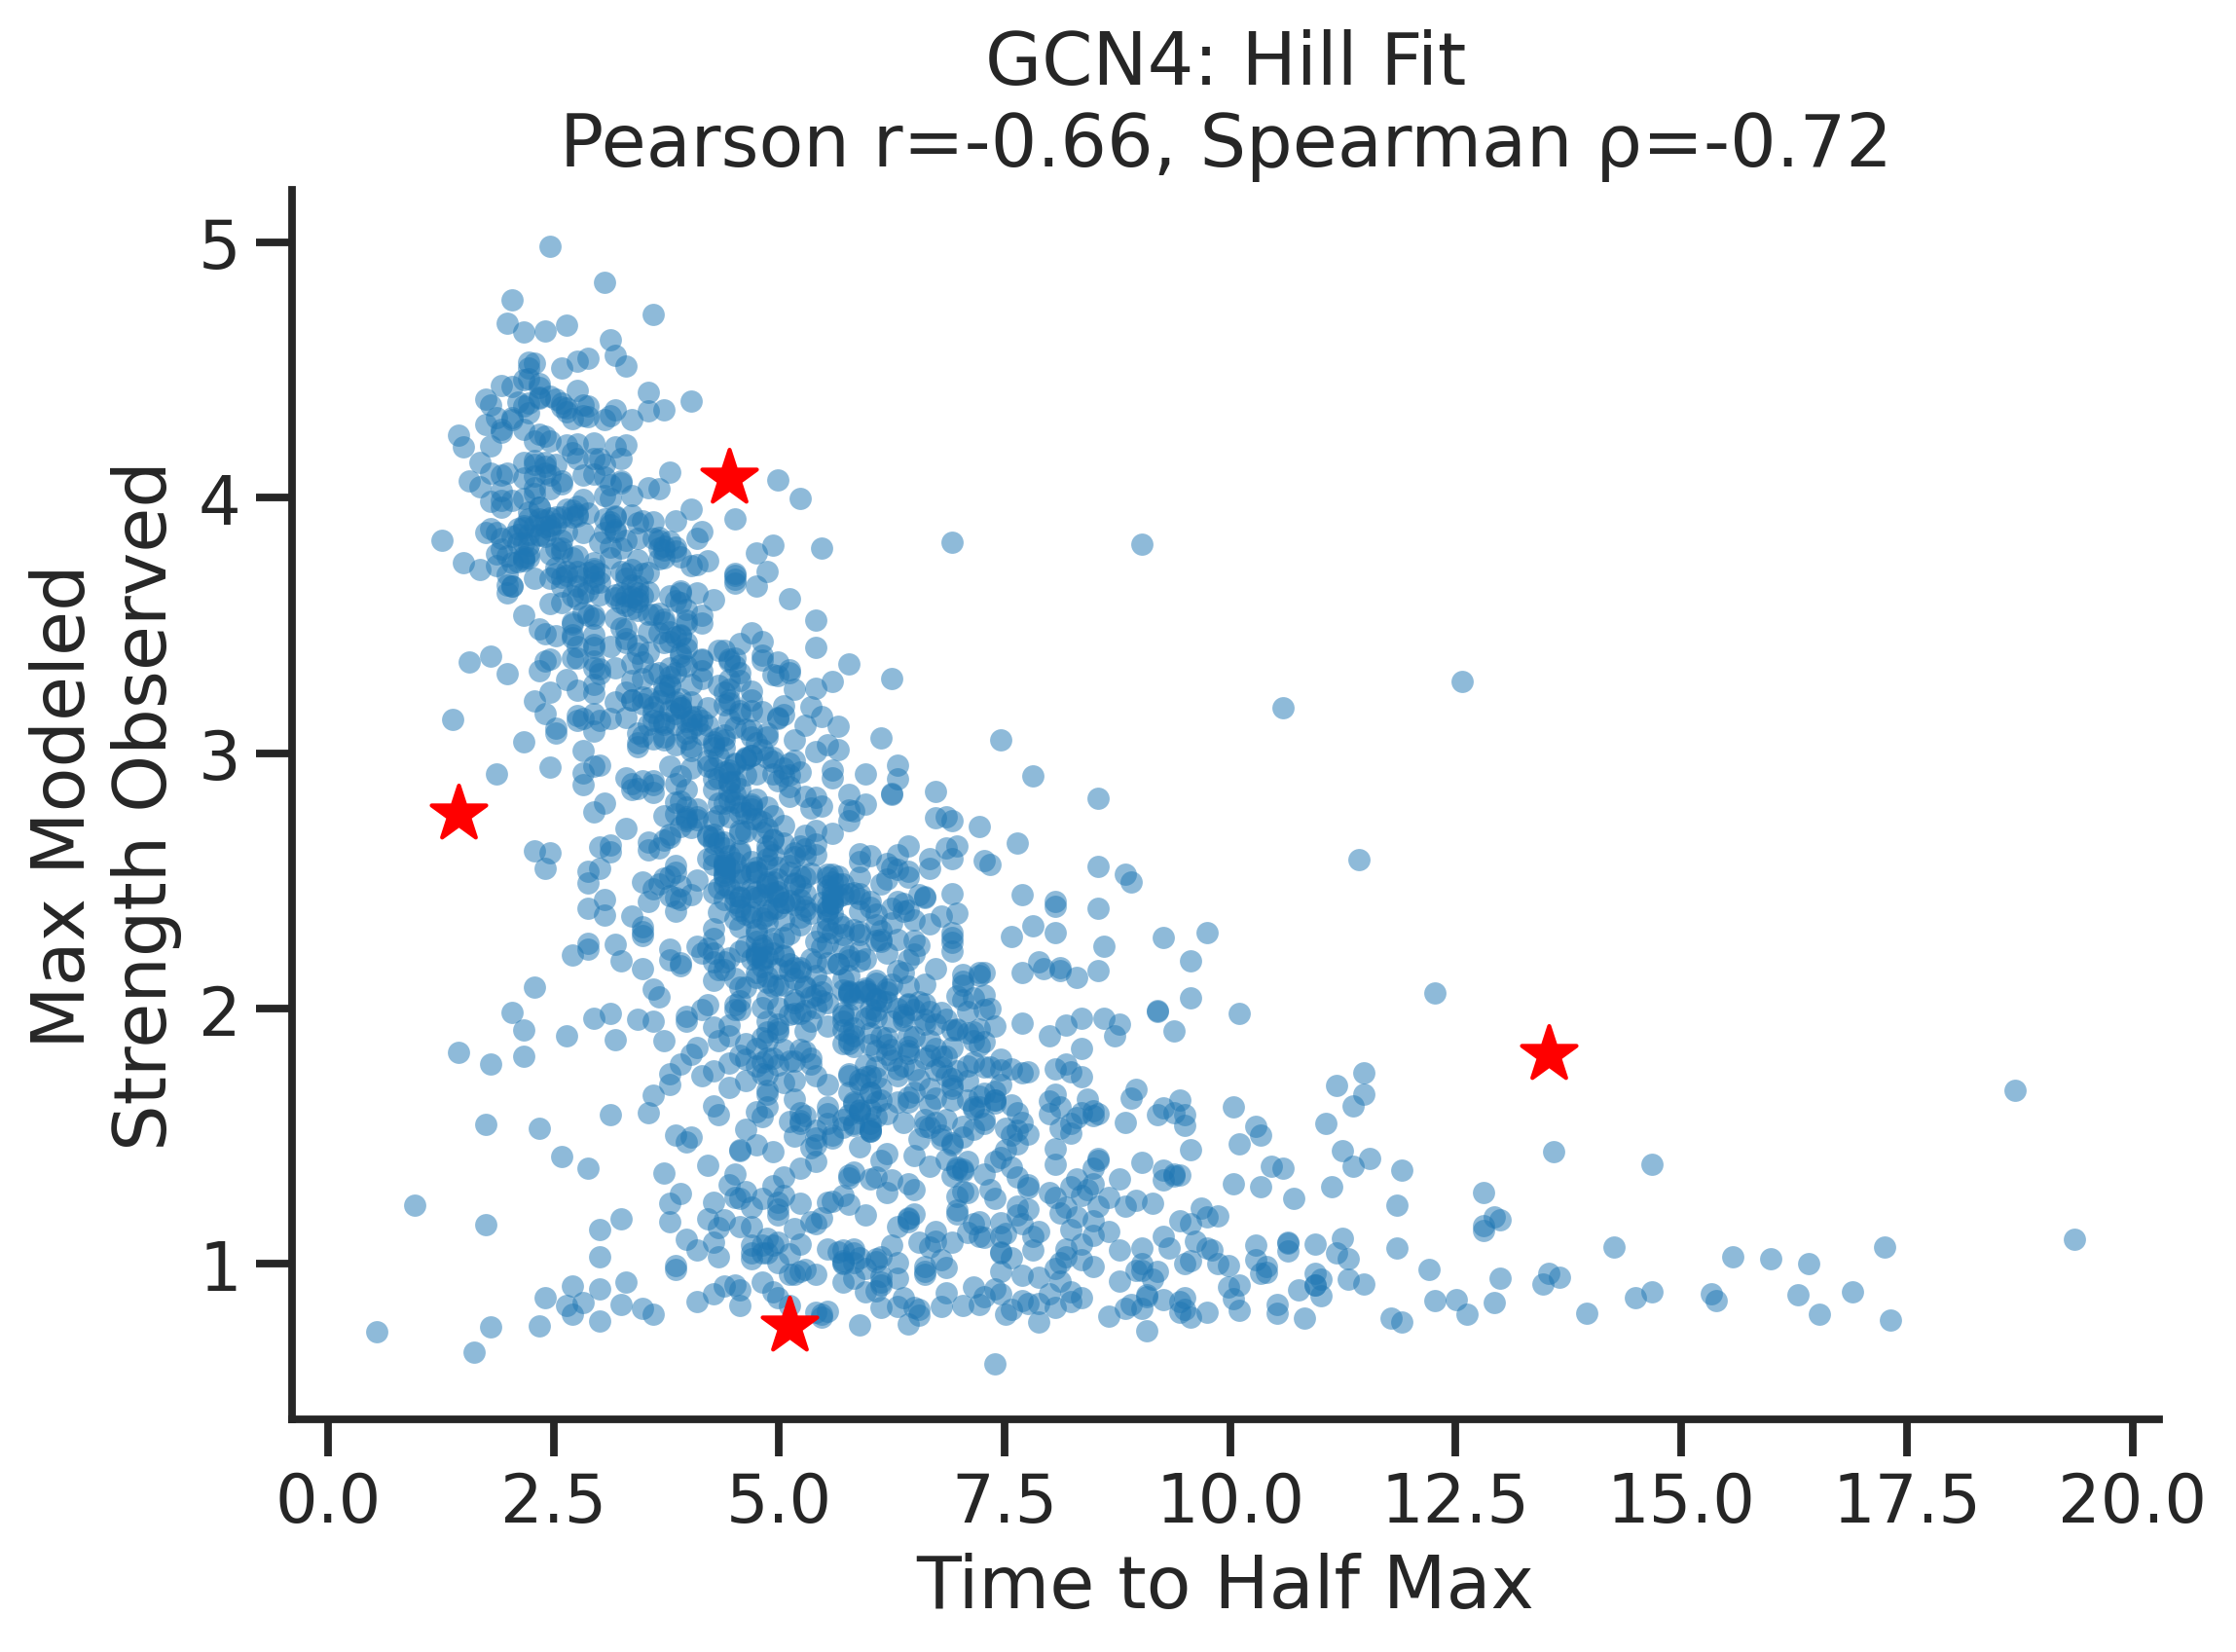

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

sns.set_context('talk')

# --- calculate correlations ---
pearson_corr, pearson_p = pearsonr(ok['t_half_obs'], ok ['obs_max'])
spearman_corr, spearman_p = spearmanr(ok['t_half_obs'], ok ['obs_max'])

print(f"Pearson r = {pearson_corr:.3f}, p = {pearson_p:.3g}")
print(f"Spearman rho = {spearman_corr:.3f}, p = {spearman_p:.3g}")

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 6), dpi = 300)

sc = ax.scatter(
    ok['t_half_obs'], ok['obs_max'],
    alpha=0.5,
    s=30,
    linewidths=0
)

ax.scatter(
    to_plot['t_half_obs'], to_plot['obs_max'],
    alpha=1,
    s=200,
    linewidths=1,
    edgecolors='red',
    color='red',
    marker = '*'
)

ax.set_xlabel('Time to Half Max')
ax.set_ylabel('Max Modeled\nStrength Observed')
ax.set_title(f'GCN4: Hill Fit\nPearson r={pearson_corr:.2f}, Spearman ρ={spearman_corr:.2f}')

# ax.set_xlim(0,31)
# ax.set_ylim(0,2.5)

plt.tight_layout()
sns.despine()
plt.show()

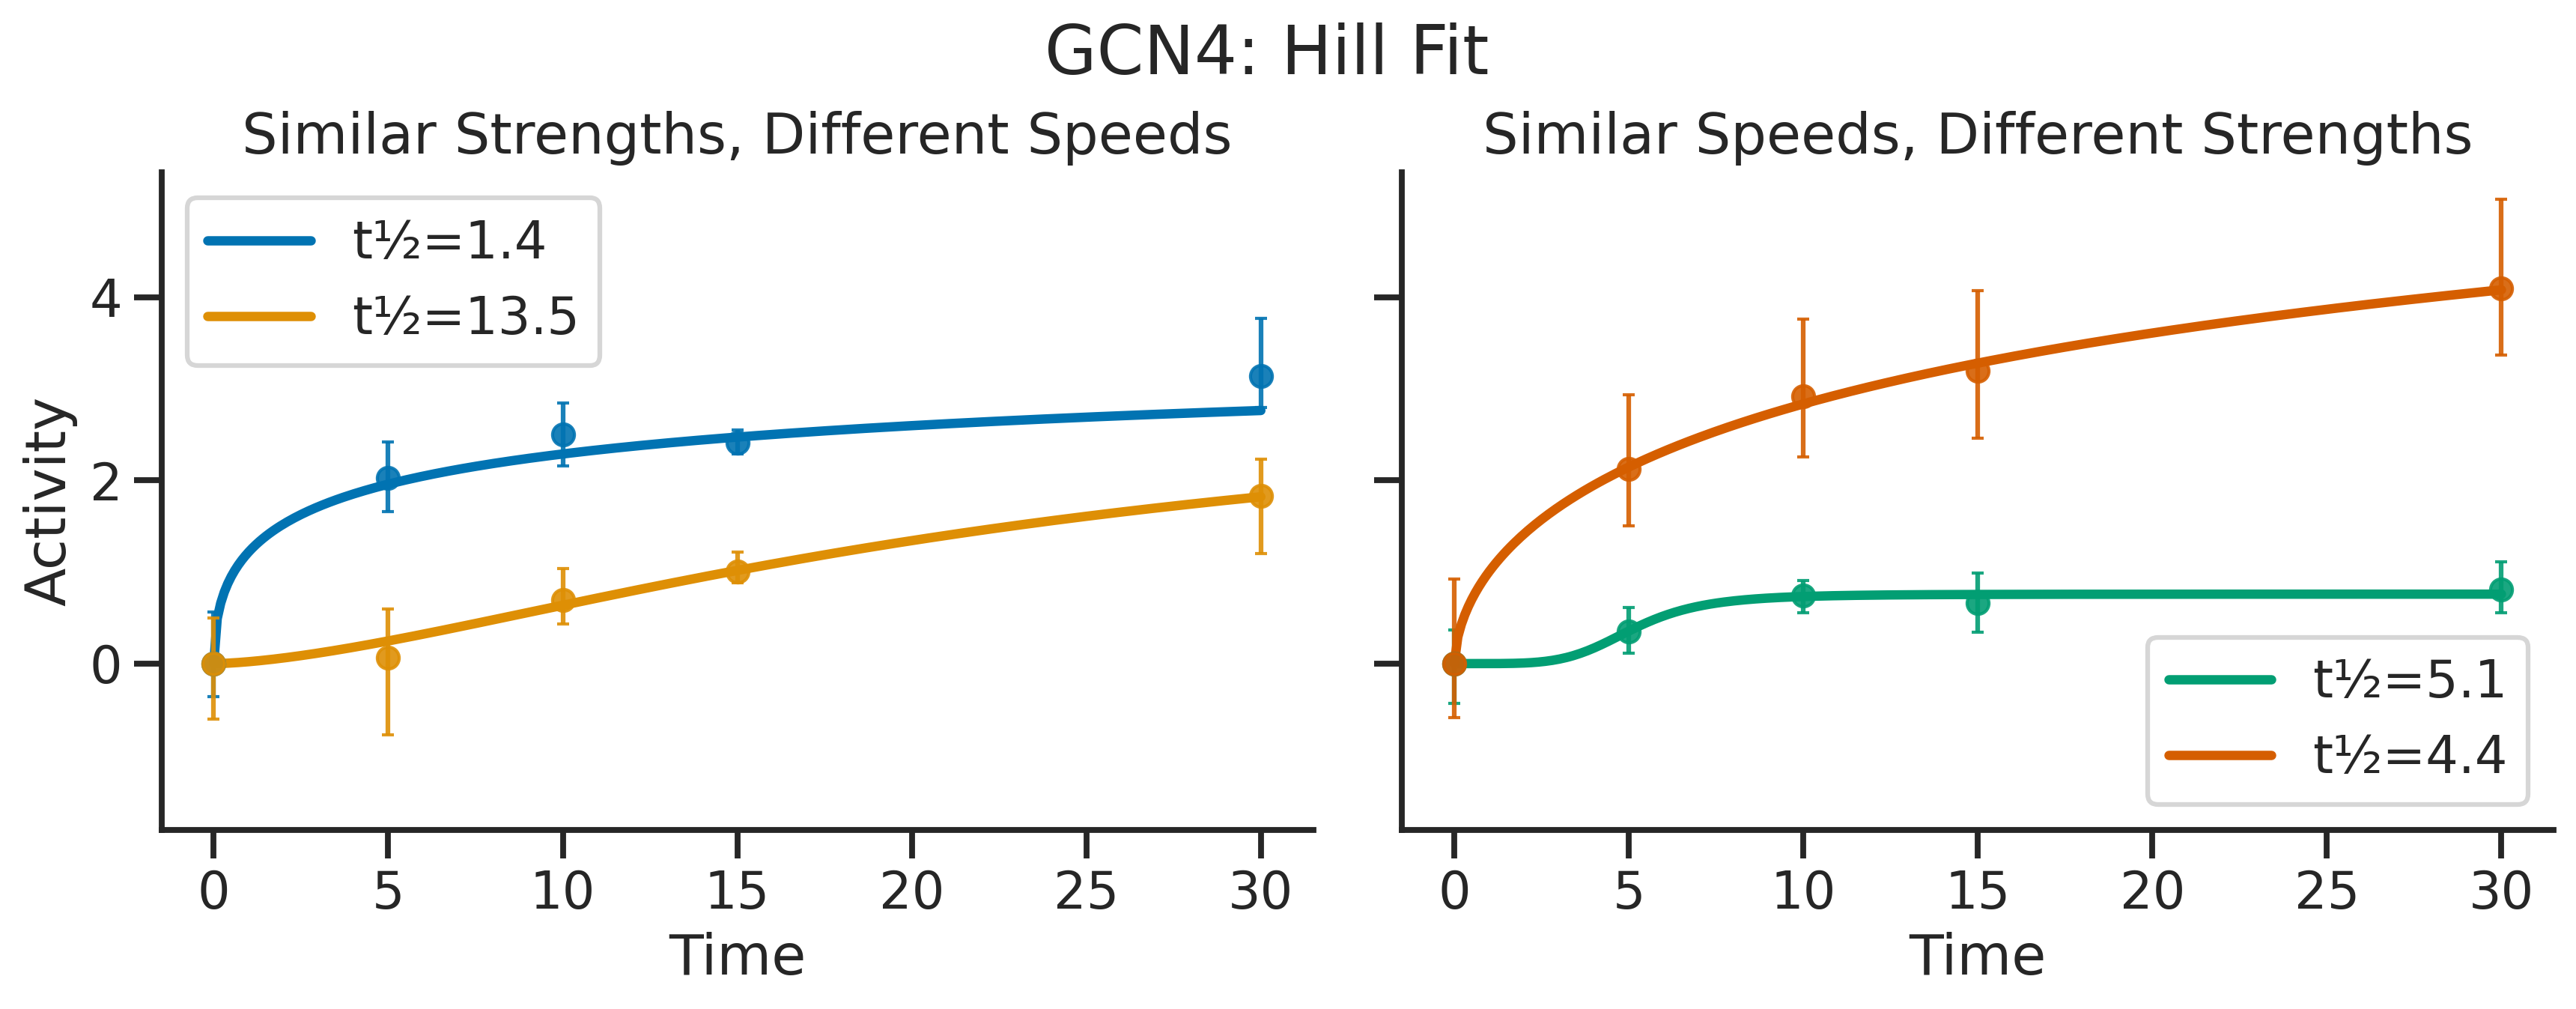

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# --- Hill function ---
def hill(t, Vmax, K, n):
    return Vmax * (t**n) / (K**n + t**n)

t_fine = np.linspace(0, activities['time'].max(), 300)
colors = sns.color_palette('colorblind', n_colors=4)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True, dpi=300)

# -----------------------------
# Similar Strength, Different Speeds
# -----------------------------
for idx in [0, 1]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[0].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[0].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Activity')
axs[0].set_title("Similar Strengths, Different Speeds")
axs[0].legend()
sns.despine(ax=axs[0])

# -----------------------------
# Similar Speed, Different Strengths
# -----------------------------
for idx in [2, 3]:

    row = to_plot.iloc[idx]

    grp = activities[activities['ADseq'] == row['ADseq']].sort_values('time')
    t = grp['time'].values
    y = grp['activity_norm'].values

    # --- asymmetric CI error bars ---
    lower_err = y - grp['ci_low_norm'].values
    upper_err = grp['ci_hi_norm'].values - y

    lower_err = np.maximum(0, lower_err)
    upper_err = np.maximum(0, upper_err)

    axs[1].errorbar(
        t, y,
        yerr=[lower_err, upper_err],
        fmt='o',
        color=colors[idx],
        ecolor=colors[idx],
        elinewidth=1.5,
        capsize=2,
        markersize=7,
        alpha=0.9
    )

    if row['success'] and np.isfinite(row['Vmax']):
        axs[1].plot(
            t_fine,
            hill(t_fine, row['Vmax'], row['K_fit'], row['n']),
            color=colors[idx],
            linewidth=3,
            label=f"t½={row['t_half_obs']:.1f}"
        )

axs[1].set_xlabel('Time')
axs[1].set_title("Similar Speeds, Different Strengths")
axs[1].legend()
sns.despine(ax=axs[1])

# -----------------------------
# shared y-axis scaling
# -----------------------------
grps = activities[activities['ADseq'].isin(to_plot['ADseq'])]

y_min = (grps['activity_norm'] - (grps['ci_hi'] - grps['activity_norm'])).min()

for ax in axs:
    ax.set_ylim(bottom=y_min)

plt.suptitle("GCN4: Hill Fit", y=0.912)
plt.tight_layout()
plt.show()

# 